# Ejemplo aplicado: modelo exponencial

Para un *scan* de la vesícula biliar se usa el isótopo **Tecnecio-99m**, con un tiempo de vida media aproximado de **6 horas**, aunque normalmente el seguimiento se realiza durante **24 horas**.

Se registró la siguiente intensidad relativa de radiación:

| Tiempo (h) | 0 | 1 | 3 | 5 | 7 | 9 |
|------------|---|---|---|---|---|---|
| Radiación ($\gamma$) | 1.000 | 0.891 | 0.708 | 0.562 | 0.447 | 0.355 |

La intensidad de radiación está relacionada con el tiempo mediante el modelo exponencial

$$
\gamma = Ae^{\lambda t}.
$$

Usando la transformación logarítmica del modelo exponencial:

1. Evalúe las constantes de regresión $A$ y $\lambda$.
2. Determine la vida media del Tecnecio-99m.
3. Estime la intensidad relativa de radiación después de 24 horas.

Parámetros del modelo
A = 0.999739
λ = -0.115050 h^-1

Vida media
t_1/2 = 6.0248 h

Predicción
γ(24 h) = 0.063200


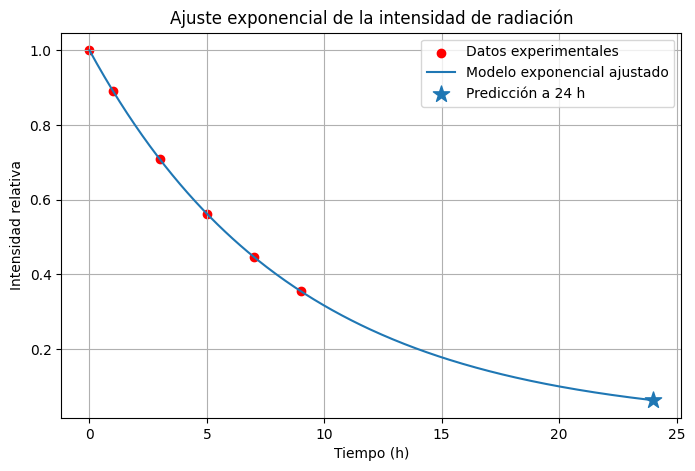

In [1]:
#Importar librerías

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

#Datos experimentales

t = np.array([0, 1, 3, 5, 7, 9], dtype=float)
gamma = np.array([1.000, 0.891, 0.708, 0.562, 0.447, 0.355], dtype=float)

#Transformación logarítmica

Y = np.log(gamma)

#Regresión lineal

resultado = linregress(t, Y)

lambda_ = resultado.slope
lnA = resultado.intercept
A = np.exp(lnA)

#Vida media

t_media = np.log(2) / (-lambda_)

#Predicción a las 24 horas

t_pred = 24
gamma_24 = A * np.exp(lambda_ * t_pred)

#Resultados

print("Parámetros del modelo")
print(f"A = {A:.6f}")
print(f"λ = {lambda_:.6f} h^-1")

print("\nVida media")
print(f"t_1/2 = {t_media:.4f} h")

print("\nPredicción")
print(f"γ(24 h) = {gamma_24:.6f}")

#Curva ajustada

t_modelo = np.linspace(0, 24, 300)
gamma_modelo = A * np.exp(lambda_ * t_modelo)

#Gráfica

plt.figure(figsize=(8,5))
plt.scatter(t, gamma, color='red', label='Datos experimentales')
plt.plot(t_modelo, gamma_modelo, label='Modelo exponencial ajustado')
plt.scatter(t_pred, gamma_24, marker='*', s=150, label='Predicción a 24 h')

plt.xlabel("Tiempo (h)")
plt.ylabel("Intensidad relativa")
plt.title("Ajuste exponencial de la intensidad de radiación")
plt.grid(True)
plt.legend()

plt.show()